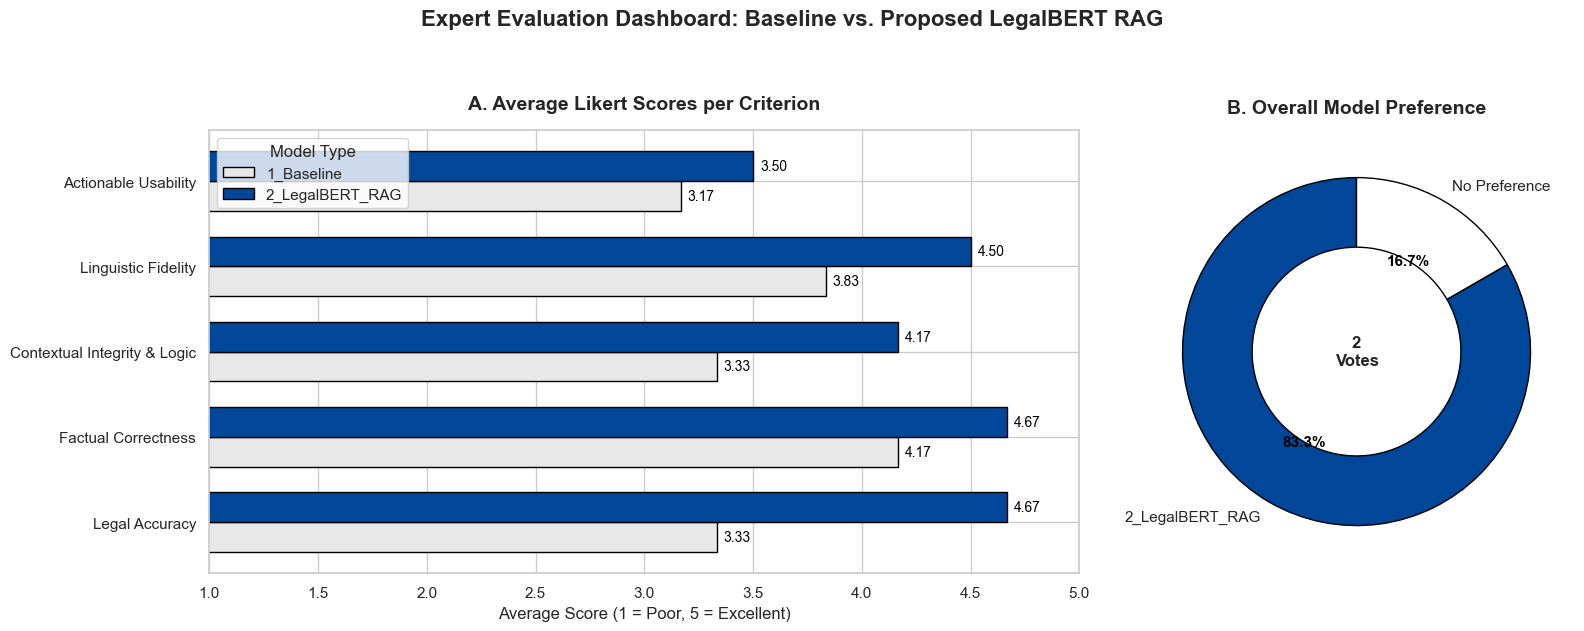

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_combined_expert_evaluation(csv_path: str):

    df_raw = pd.read_csv(csv_path)
    df_experts = df_raw.iloc[2:].copy()
    
    criteria_names = [
        'Legal Accuracy',
        'Factual Correctness',
        'Contextual Integrity & Logic',
        'Linguistic Fidelity',
        'Actionable Usability'
    ]

    baseline_cols = {
        'Legal Accuracy':               ['QID1_1', 'QID6_2', 'Zaak 3_1'],
        'Factual Correctness':          ['QID1_3', 'QID6_4', 'Zaak 3_3'],
        'Contextual Integrity & Logic': ['QID1_5', 'QID6_6', 'Zaak 3_5'],
        'Linguistic Fidelity':          ['QID1_7', 'QID6_8', 'Zaak 3_7'],
        'Actionable Usability':         ['QID1_9', 'QID6_10', 'Zaak 3_9']
    }
    
    rag_cols = {
        'Legal Accuracy':               ['QID1_2', 'Q6_1', 'Zaak 3_2'] if 'Q6_1' in df_experts.columns else ['QID1_2', 'QID6_1', 'Zaak 3_2'],
        'Factual Correctness':          ['QID1_4', 'Q6_3', 'Zaak 3_4'] if 'Q6_3' in df_experts.columns else ['QID1_4', 'QID6_3', 'Zaak 3_4'],
        'Contextual Integrity & Logic': ['QID1_6', 'Q6_5', 'Zaak 3_6'] if 'Q6_5' in df_experts.columns else ['QID1_6', 'QID6_5', 'Zaak 3_6'],
        'Linguistic Fidelity':          ['QID1_8', 'Q6_7', 'Zaak 3_8'] if 'Q6_7' in df_experts.columns else ['QID1_8', 'QID6_7', 'Zaak 3_8'],
        'Actionable Usability':         ['QID1_10', 'Q6_9', 'Zaak 3_10'] if 'Q6_9' in df_experts.columns else ['QID1_10', 'QID6_9', 'Zaak 3_10']
    }

    
    for k in rag_cols.keys():
        rag_cols[k] = [c if c in df_experts.columns else c.replace('QID6', 'QID6') for c in rag_cols[k]]

    all_cols = [c for sublist in baseline_cols.values() for c in sublist] + \
               [c for sublist in rag_cols.values() for c in sublist]
               
    for col in all_cols:
        if col in df_experts.columns:
            df_experts[col] = df_experts[col].astype(str).str.extract(r'(\d+)').astype(float)

    results = []
    for crit in criteria_names:
        base_vals = df_experts[baseline_cols[crit]].values.flatten()
        base_mean = base_vals[~np.isnan(base_vals)].mean()
        
        rag_vals = df_experts[rag_cols[crit]].values.flatten()
        rag_mean = rag_vals[~np.isnan(rag_vals)].mean()
        
        results.append({'Criterion': crit, '1_Baseline': base_mean, '2_LegalBERT_RAG': rag_mean})
        
    df_plot = pd.DataFrame(results).set_index('Criterion')

    preferences = {'1_Baseline': 0, '2_LegalBERT_RAG': 0, 'No Preference': 0}
    
    if 'QID13' in df_experts.columns:
        for val in df_experts['QID13'].dropna():
            v = int(float(val))
            if v == 1: preferences['1_Baseline'] += 1
            elif v == 2: preferences['2_LegalBERT_RAG'] += 1
            elif v == 3: preferences['No Preference'] += 1
            
    if 'QID14' in df_experts.columns:
        for val in df_experts['QID14'].dropna():
            v = int(float(val))
            if v == 1: preferences['2_LegalBERT_RAG'] += 1
            elif v == 2: preferences['1_Baseline'] += 1
            elif v == 3: preferences['No Preference'] += 1

    if 'QID15' in df_experts.columns:
        for val in df_experts['QID15'].dropna():
            v = int(float(val))
            if v == 1: preferences['1_Baseline'] += 1
            elif v == 2: preferences['2_LegalBERT_RAG'] += 1
            elif v == 3: preferences['No Preference'] += 1

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})
    
    colors_bar = ['#e8e8e8', '#004699'] 
    df_plot.plot(kind='barh', ax=axes[0], color=colors_bar, width=0.7, edgecolor='black')
    
    axes[0].set_title("A. Average Likert Scores per Criterion", fontsize=14, weight='bold', pad=15)
    axes[0].set_xlabel("Average Score (1 = Poor, 5 = Excellent)", fontsize=12)
    axes[0].set_ylabel("")
    axes[0].set_xlim(1.0, 5.0)
    axes[0].legend(title="Model Type", loc='upper left')
    
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.2f', label_type='edge', padding=5, color='black', fontsize=10)

    pref_labels = list(preferences.keys())
    pref_sizes = list(preferences.values())
    pref_colors = ['#e8e8e8', '#004699', 'white']
    
    filtered_labels = [l for l, s in zip(pref_labels, pref_sizes) if s > 0]
    filtered_sizes = [s for s in pref_sizes if s > 0]
    filtered_colors = [c for c, s in zip(pref_colors, pref_sizes) if s > 0]

    wedges, texts, autotexts = axes[1].pie(
        filtered_sizes, 
        labels=filtered_labels, 
        colors=filtered_colors, 
        autopct='%1.1f%%', 
        startangle=90,
        wedgeprops=dict(width=0.4, edgecolor='black')
    )
    
    plt.setp(autotexts, size=11, weight="bold", color="black")
    plt.setp(texts, size=11)
    
    total_votes = 2
    axes[1].text(0, 0, f"{total_votes}\nVotes", ha='center', va='center', fontsize=12, weight='bold')
    axes[1].set_title("B. Overall Model Preference", fontsize=14, weight='bold', pad=15)

    plt.suptitle("Expert Evaluation Dashboard: Baseline vs. Proposed LegalBERT RAG", fontsize=16, weight='bold', y=1.05)
    plt.tight_layout()
    
    os.makedirs("figures", exist_ok=True)
    save_path = "figures/expert_combined_evaluation.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

file_path = "Data/Interview LegalWriter_June 15, 2026_07.29.csv"
plot_combined_expert_evaluation(file_path)

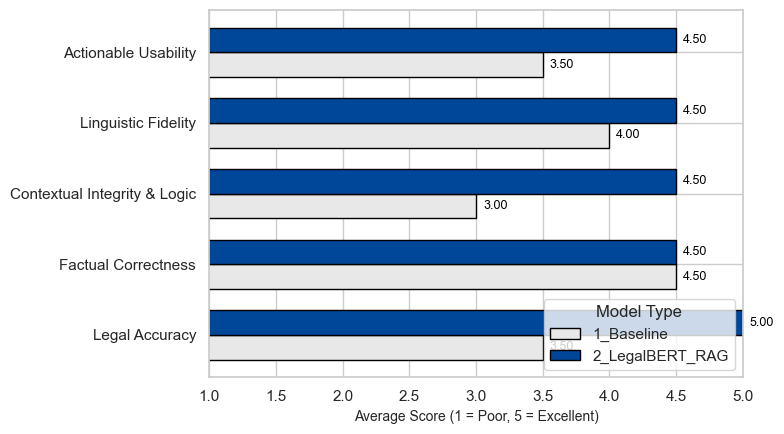

In [24]:


def plot_case1_evaluation(csv_path: str):
    df_raw = pd.read_csv(csv_path)
    df_experts = df_raw.iloc[2:].copy()
    
    criteria_names = [
        'Legal Accuracy',
        'Factual Correctness',
        'Contextual Integrity & Logic',
        'Linguistic Fidelity',
        'Actionable Usability'
    ]

    baseline_cols = {
        'Legal Accuracy': 'QID1_1',
        'Factual Correctness': 'QID1_3',
        'Contextual Integrity & Logic': 'QID1_5',
        'Linguistic Fidelity': 'QID1_7',
        'Actionable Usability': 'QID1_9'
    }
    
    rag_cols = {
        'Legal Accuracy': 'QID1_2',
        'Factual Correctness': 'QID1_4',
        'Contextual Integrity & Logic': 'QID1_6',
        'Linguistic Fidelity': 'QID1_8',
        'Actionable Usability': 'QID1_10'
    }

    for col in list(baseline_cols.values()) + list(rag_cols.values()):
        if col in df_experts.columns:
            df_experts[col] = df_experts[col].astype(str).str.extract(r'(\d+)').astype(float)

    results = []
    for crit in criteria_names:
        base_vals = df_experts[baseline_cols[crit]].values
        base_mean = np.nanmean(base_vals) if not np.all(np.isnan(base_vals)) else 1.0
        
        rag_vals = df_experts[rag_cols[crit]].values
        rag_mean = np.nanmean(rag_vals) if not np.all(np.isnan(rag_vals)) else 1.0
        
        results.append({'Criterion': crit, '1_Baseline': base_mean, '2_LegalBERT_RAG': rag_mean})
        
    df_plot = pd.DataFrame(results).set_index('Criterion')

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    colors_bar = ['#e8e8e8', '#004699'] 
    
    df_plot.plot(kind='barh', ax=ax, color=colors_bar, width=0.7, edgecolor='black')
    
    ax.set_xlabel("Average Score (1 = Poor, 5 = Excellent)", fontsize=10)
    ax.set_ylabel("")
    ax.set_xlim(1.0, 5.0)
    ax.legend(title="Model Type", loc='lower right')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', padding=5, color='black', fontsize=9)

    plt.tight_layout()
    os.makedirs("figures", exist_ok=True)
    plt.savefig("figures/likert_case1.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


plot_case1_evaluation("Data/Interview LegalWriter_June 15, 2026_07.29.csv")

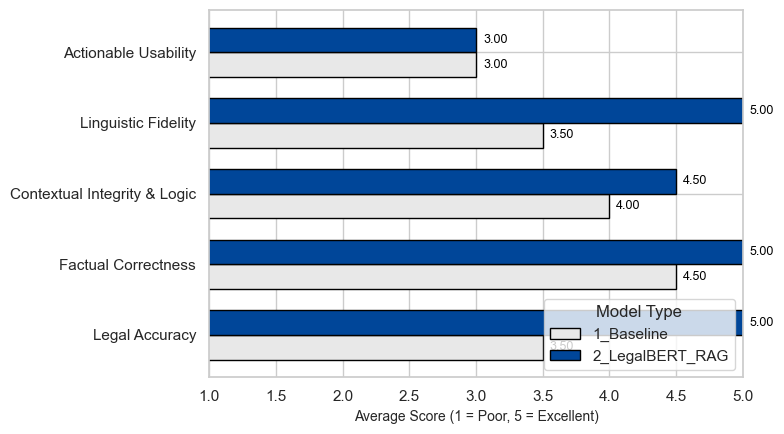

In [25]:

def plot_case2_evaluation(csv_path: str):
    df_raw = pd.read_csv(csv_path)
    df_experts = df_raw.iloc[2:].copy()
    
    criteria_names = [
        'Legal Accuracy',
        'Factual Correctness',
        'Contextual Integrity & Logic',
        'Linguistic Fidelity',
        'Actionable Usability'
    ]

    baseline_cols = {
        'Legal Accuracy': 'QID6_2',
        'Factual Correctness': 'QID6_4',
        'Contextual Integrity & Logic': 'QID6_6',
        'Linguistic Fidelity': 'QID6_8',
        'Actionable Usability': 'QID6_10'
    }
    
    rag_cols = {
        'Legal Accuracy': 'Q6_1' if 'Q6_1' in df_experts.columns else 'QID6_1',
        'Factual Correctness': 'Q6_3' if 'Q6_3' in df_experts.columns else 'QID6_3',
        'Contextual Integrity & Logic': 'Q6_5' if 'Q6_5' in df_experts.columns else 'QID6_5',
        'Linguistic Fidelity': 'Q6_7' if 'Q6_7' in df_experts.columns else 'QID6_7',
        'Actionable Usability': 'Q6_9' if 'Q6_9' in df_experts.columns else 'QID6_10'
    }

    for col in list(baseline_cols.values()) + list(rag_cols.values()):
        if col in df_experts.columns:
            df_experts[col] = df_experts[col].astype(str).str.extract(r'(\d+)').astype(float)

    results = []
    for crit in criteria_names:
        base_vals = df_experts[baseline_cols[crit]].values
        base_mean = np.nanmean(base_vals) if not np.all(np.isnan(base_vals)) else 1.0
        
        rag_vals = df_experts[rag_cols[crit]].values
        rag_mean = np.nanmean(rag_vals) if not np.all(np.isnan(rag_vals)) else 1.0
        
        results.append({'Criterion': crit, '1_Baseline': base_mean, '2_LegalBERT_RAG': rag_mean})
        
    df_plot = pd.DataFrame(results).set_index('Criterion')

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    colors_bar = ['#e8e8e8', '#004699'] 
    
    df_plot.plot(kind='barh', ax=ax, color=colors_bar, width=0.7, edgecolor='black')
    
    ax.set_xlabel("Average Score (1 = Poor, 5 = Excellent)", fontsize=10)
    ax.set_ylabel("")
    ax.set_xlim(1.0, 5.0)
    ax.legend(title="Model Type", loc='lower right')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', padding=5, color='black', fontsize=9)

    plt.tight_layout()
    plt.savefig("figures/likert_case2.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

plot_case2_evaluation("Data/Interview LegalWriter_June 15, 2026_07.29.csv")

In [26]:

def plot_case3_evaluation(csv_path: str):
    df_raw = pd.read_csv(csv_path)
    df_experts = df_raw.iloc[2:].copy()
    
    criteria_names = [
        'Legal Accuracy',
        'Factual Correctness',
        'Contextual Integrity & Logic',
        'Linguistic Fidelity',
        'Actionable Usability'
    ]

    baseline_cols = {
        'Legal Accuracy': 'Zaak 3_1',
        'Factual Correctness': 'Zaak 3_3',
        'Contextual Integrity & Logic': 'Zaak 3_5',
        'Linguistic Fidelity': 'Zaak 3_7',
        'Actionable Usability': 'Zaak 3_9'
    }
    
    rag_cols = {
        'Legal Accuracy': 'Zaak 3_2',
        'Factual Correctness': 'Zaak 3_4',
        'Contextual Integrity & Logic': 'Zaak 3_6',
        'Linguistic Fidelity': 'Zaak 3_8',
        'Actionable Usability': 'Zaak 3_10'
    }

    for col in list(baseline_cols.values()) + list(rag_cols.values()):
        if col in df_experts.columns:
            df_experts[col] = df_experts[col].astype(str).str.extract(r'(\d+)').astype(float)

    results = []
    for crit in criteria_names:
        base_vals = df_experts[baseline_cols[crit]].values
        base_mean = np.nanmean(base_vals) if not np.all(np.isnan(base_vals)) else 1.0
        
        rag_vals = df_experts[rag_cols[crit]].values
        rag_mean = np.nanmean(rag_vals) if not np.all(np.isnan(rag_vals)) else 1.0
        
        results.append({'Criterion': crit, '1_Baseline': base_mean, '2_LegalBERT_RAG': rag_mean})
        
    df_plot = pd.DataFrame(results).set_index('Criterion')

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    colors_bar = ['#e8e8e8', '#004699'] 
    
    df_plot.plot(kind='barh', ax=ax, color=colors_bar, width=0.7, edgecolor='black')
    
    ax.set_xlabel("Average Score (1 = Poor, 5 = Excellent)", fontsize=10)
    ax.set_ylabel("")
    ax.set_xlim(1.0, 5.0)
    ax.legend(title="Model Type", loc='lower right')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', padding=5, color='black', fontsize=9)

    plt.tight_layout()
    plt.savefig("figures/likert_case3.png", dpi=300, bbox_inches='tight')
    plt.close()

plot_case3_evaluation("Data/Interview LegalWriter_June 15, 2026_07.29.csv")